<a href="https://colab.research.google.com/github/wangyixinxinyiwang/Public-Opinion-Analysis-of-Richard-Liu-Delivering-Food/blob/main/%E5%88%98%E5%BC%BA%E4%B8%9C%E9%80%81%E5%A4%96%E5%8D%96%E8%88%86%E6%83%85%E5%88%86%E6%9E%90-%E6%8A%96%E9%9F%B3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_excel('/content/副本douyin2.xlsx')
df.head()

,Comment,Username
0,看吧 人一旦开始打工 看起来就很命苦的样子,转转转太阳
1,东哥停止交易，有内鬼,小王很棒
2,东哥喝了酒也是跟我们状态一样啊，,带刀的二蛋Dream
3,看吧，就连刘强东上班也这个表情,无尘之境
4,东哥，一定要善待投诚过来了兄弟啊,苗岭


In [ ]:
print("Displaying the first 5 rows of the DataFrame:")
print(df.head())

print("\nDisplaying DataFrame information (column names, non-null counts, and data types):")
df.info()

print("\nDisplaying column names:")
print(df.columns)

Displaying the first 5 rows of the DataFrame:
                  Comment    Username
0  看吧  人一旦开始打工 看起来就很命苦的样子       转转转太阳
1              东哥停止交易，有内鬼        小王很棒
2        东哥喝了酒也是跟我们状态一样啊，  带刀的二蛋Dream
3         看吧，就连刘强东上班也这个表情        无尘之境
4        东哥，一定要善待投诚过来了兄弟啊          苗岭

Displaying DataFrame information (column names, non-null counts, and data types):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 765 entries, 0 to 764
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Comment   746 non-null    object
 1   Username  761 non-null    object
dtypes: object(2)
memory usage: 12.1+ KB

Displaying column names:
Index(['Comment', 'Username'], dtype='object')


In [ ]:
print("Missing values before handling:\n", df.isnull().sum())

Missing values before handling:
 Comment     19
Username     4
dtype: int64


In [ ]:
df.dropna(inplace=True)
print("Missing values after dropping rows with any nulls:\n", df.isnull().sum())

Missing values after dropping rows with any nulls:
 Comment     0
Username    0
dtype: int64


```markdown
### Subtask
识别并删除DataFrame中的重复行，以确保数据唯一性。

#### Instructions
1. 使用 `df.duplicated().sum()` 检查DataFrame中是否存在重复行，并查看重复行的数量。
2. 使用 `df.drop_duplicates(inplace=True)` 删除所有重复行，确保每行数据的唯一性。
3. 再次使用 `df.duplicated().sum()` 确认所有重复行均已处理。

```

In [ ]:
print("Number of duplicate rows before handling:", df.duplicated().sum())

Number of duplicate rows before handling: 1


In [ ]:
df.drop_duplicates(inplace=True)
print("Number of duplicate rows after handling:", df.duplicated().sum())

Number of duplicate rows after handling: 0


In [ ]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return text
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = re.sub(r'[^一-龥a-zA-Z\s]', '', text) # Keep Chinese, English letters and spaces
    # Remove numbers (already handled by the above regex if only keeping specific chars)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Comment'] = df['Comment'].apply(clean_text)
print("First 5 rows of 'Comment' column after cleaning:")
print(df['Comment'].head())

First 5 rows of 'Comment' column after cleaning:
0    看吧 人一旦开始打工 看起来就很命苦的样子
1                东哥停止交易有内鬼
2          东哥喝了酒也是跟我们状态一样啊
3           看吧就连刘强东上班也这个表情
4          东哥一定要善待投诚过来了兄弟啊
Name: Comment, dtype: object


In [ ]:
pip install snownlp

In [ ]:
from snownlp import SnowNLP

def get_sentiment_score(text):
    if isinstance(text, str):
        s = SnowNLP(text)
        return s.sentiments
    return None

df['sentiment_score'] = df['Comment'].apply(get_sentiment_score)
print("First 5 rows of DataFrame with sentiment scores:")
print(df.head())

First 5 rows of DataFrame with sentiment scores:
                                              Comment         Username  \
0                               看吧 人一旦开始打工 看起来就很命苦的样子            转转转太阳   
1                                           东哥停止交易有内鬼             小王很棒   
2                                     东哥喝了酒也是跟我们状态一样啊       带刀的二蛋Dream   
3                                      看吧就连刘强东上班也这个表情             无尘之境   
4                                     东哥一定要善待投诚过来了兄弟啊               苗岭   
5                                                东哥现状             小球同学   
6                                        京东上看到的是不是真的呢              雨泽@   
7                             我前男友如果放弃某团过来京东的话我会考虑原谅他               莎莎   
8                                            这两个是干什么的           美业线上获客   
9                                       东哥也老了呀京东外卖用起来              小文子   
10                               京东外卖在哪里点啊搞了半天注册成为骑手了              bot   
11             我还欠我东哥几万元逾期好久了东哥真接地气我现在准备跑京东外卖给我东哥把钱还了          

### Sentiment Category Pie Chart

Let's visualize the distribution of sentiment categories using a pie chart to see the proportion of positive, neutral, and negative comments.

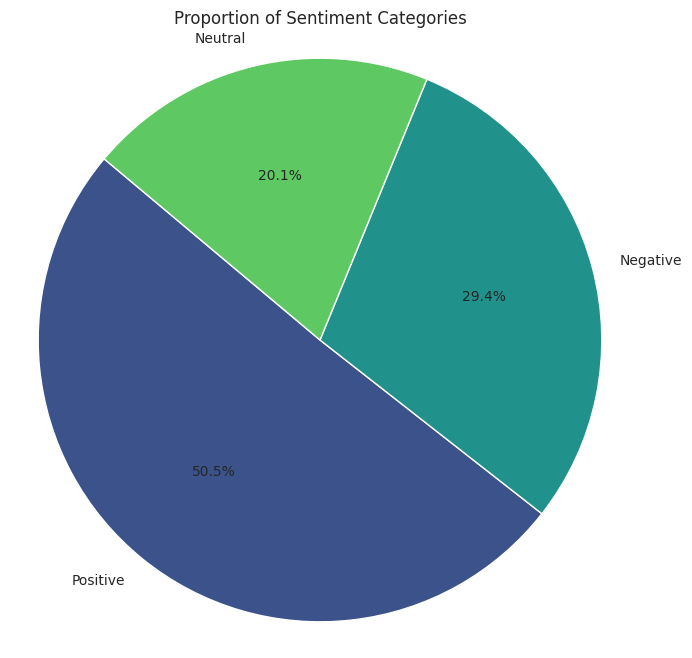

In [ ]:
import matplotlib.pyplot as plt

# Create a pie chart of sentiment categories
plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(sentiment_counts)))
plt.title('Proportion of Sentiment Categories')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Word Cloud of Comments

To understand the most frequently used words in the comments, let's generate a word cloud. Since the comments are in Chinese, we'll use `jieba` for word segmentation.

In [ ]:
pip install wordcloud jieba

Chinese font 'fonts-wqy-zenhei' already installed.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32769 (\N{CJK UNIFIED IDEOGRAPH-8001}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


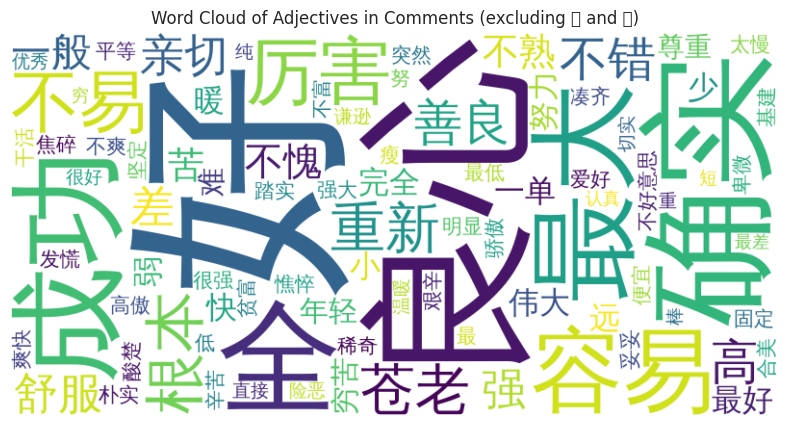

In [ ]:
from wordcloud import WordCloud
import jieba.posseg as pseg
import matplotlib.pyplot as plt
import os

# Install Chinese font if not already installed or if previous font caused issues
font_path = '/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc'

if not os.path.exists(font_path):
    print("Installing Chinese font 'fonts-wqy-zenhei'...")
    try:
        !apt-get -qq install -y fonts-wqy-zenhei
        print("Chinese font installed successfully.")
    except Exception as e:
        print(f"Error installing font: {e}")
        print("Falling back to a default font (Chinese characters may not display correctly).")
        font_path = None # Indicate that a proper Chinese font couldn't be set
else:
    print("Chinese font 'fonts-wqy-zenhei' already installed.")

# Concatenate all comments into a single string
all_comments = ' '.join(df['Comment'].astype(str))

# Use jieba for Chinese word segmentation and part-of-speech tagging
words_with_pos = pseg.cut(all_comments)

# Filter for adjectives (tag 'a') and exclude specified words
excluded_words = {'老', '大'}
adjectives = [word for word, flag in words_with_pos if 'a' in flag and word not in excluded_words]
filtered_comments = ' '.join(adjectives)

# Create the word cloud object
if font_path and os.path.exists(font_path):
    wordcloud = WordCloud(width=800, height=400, background_color='white', font_path=font_path, max_words=100).generate(filtered_comments)

    # Display the generated image:
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Adjectives in Comments (excluding 老 and 大)')
    plt.show()
else:
    print("Word cloud cannot be generated due to missing or invalid font.")

The `font_path` for the word cloud was updated to install `fonts-wqy-zenhei` via `apt-get` and use its `.ttc` file. This approach is more reliable for ensuring Chinese characters are displayed correctly in the word cloud in the Colab environment. If the installation or font path acquisition fails, the word cloud might not be generated or might not render Chinese characters properly.

The word cloud generation has been modified to now filter for only adjectives (`'a'` tag from `jieba.posseg`) to show only descriptive words.

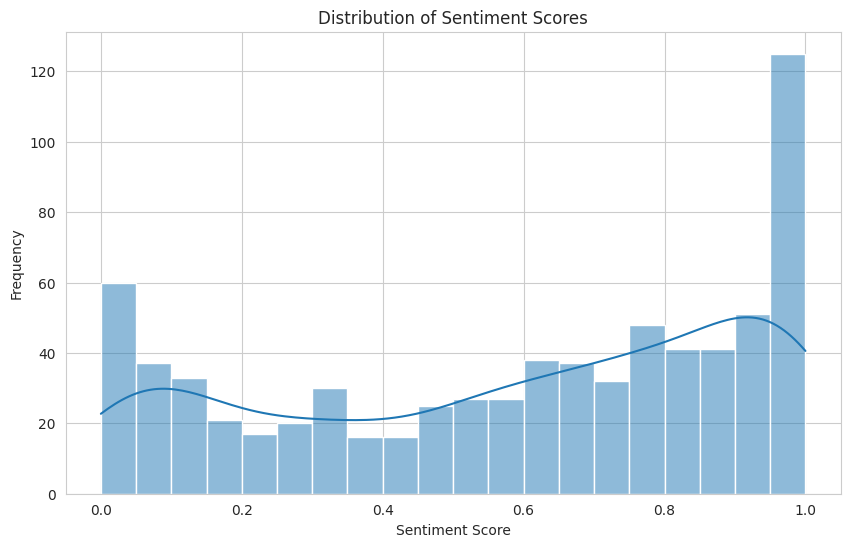

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better aesthetics
sns.set_style("whitegrid")

# Create a histogram of sentiment scores
plt.figure(figsize=(10, 6))
sns.histplot(df['sentiment_score'], bins=20, kde=True)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

### Sentiment Category Distribution

Next, let's categorize the sentiment scores into 'Positive', 'Neutral', and 'Negative' based on common thresholds and visualize their distribution using a bar chart.

/tmp/ipykernel_2467/1473393014.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


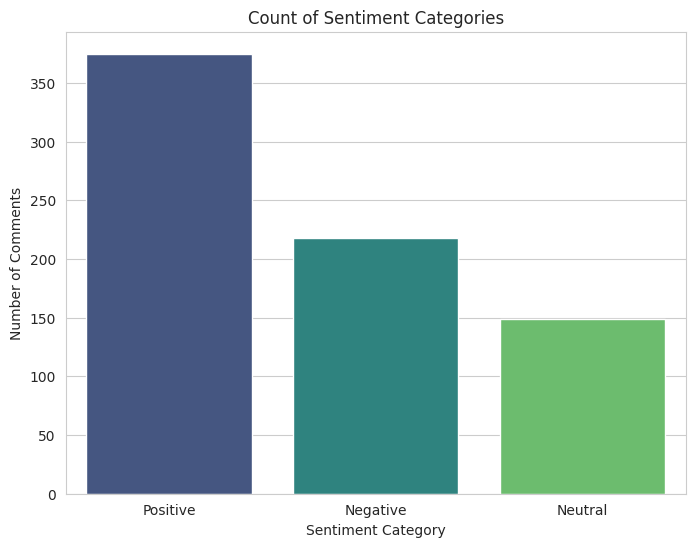

In [ ]:
# Define sentiment categories
def categorize_sentiment(score):
    if score > 0.65: # Threshold for positive sentiment
        return 'Positive'
    elif score < 0.35: # Threshold for negative sentiment
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment_score'].apply(categorize_sentiment)

# Count the occurrences of each category
sentiment_counts = df['sentiment_category'].value_counts()

# Create a bar chart of sentiment categories
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Count of Sentiment Categories')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Comments')
plt.show()

The `sentiment_score` ranges from 0 to 1, where values closer to 1 indicate positive sentiment and values closer to 0 indicate negative sentiment. A score around 0.5 usually suggests a neutral sentiment. You can now further analyze these scores, for example, by categorizing them into positive, negative, and neutral, or by looking at their distribution.